<a href="https://colab.research.google.com/github/waghvaishnav/Deep-Learning-PlayGround-Hub/blob/main/CIFAR10_Image_Classification_using_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIFAR10 Image Classification Using the Cnvolutional Neural Networks [CNN]

### importing necessary modules

In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torchvision

In [ ]:
# assigning device:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Loading Data

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = datasets.CIFAR10(root="data",download=True,transform=transform,train=True)
test_dataset = datasets.CIFAR10(root="data",download=True,transform=transform,train=False)

In [ ]:
len(train_dataset),len(test_dataset)

(50000, 10000)

In [ ]:
# convert data into batches using dataloader

train_dataloader = DataLoader(train_dataset,batch_size=100,shuffle=True)
test_dataloader = DataLoader(test_dataset,batch_size=100)

### Visualizes Some Images

In [ ]:
for images,labels in train_dataloader:
  print(images.shape)
  print(labels.shape)
  break

torch.Size([100, 3, 32, 32])
torch.Size([100])


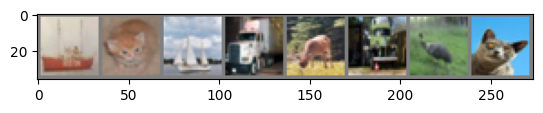

In [ ]:
# creating a function that can visualizes the images

def showimage(img):
  # 1.unnormalize the images
  img = img / 2 + 0.5
  # 2.convert the tensor to numpy array
  npimg = img.numpy()
  # 3.transpose the size of image(channel,height,width) to (height,width,channel)
  plt.imshow(np.transpose(npimg,(1,2,0)))
  plt.show()

showimage(torchvision.utils.make_grid(images[:8]))

In [ ]:
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

In [ ]:
labels[:8]

tensor([8, 3, 8, 9, 4, 9, 2, 3])

In [ ]:
[classes[i] for i in labels[:8] ]

['ship', 'cat', 'ship', 'truck', 'deer', 'truck', 'bird', 'cat']

### Train Neural Network

In [ ]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Conv2d(3,32,kernel_size=(3,3),padding="same"),   # Output: (32,32,32)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)),        # Output: (32,16,16)

        nn.Conv2d(32,64,kernel_size=(3,3)),                    # Output: (64,14,14)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=(2,2))       # Output: (64,7,7)

    )

    self.fc_layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7,600),
        nn.ReLU(),
        nn.Linear(600,120),
        nn.ReLU(),
        nn.Linear(120,10)
    )

  def forward(self,x):
    x = self.network(x)
    x = self.fc_layer(x)
    return x


In [ ]:
epochs = 10
learning_rate = 0.001

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=learning_rate)


In [ ]:
# model training:
total_step = len(train_dataloader)
model.train()
for epoch in range(epochs):
  for i,(images,labels) in enumerate(train_dataloader):
    images = images.to(device)
    labels = labels.to(device)

    # forward pass :
    output = model(images)
    loss = criterion(output,labels)

    # backpropagation:
    optimizer.zero_grad()
    loss.backward()

    # weight updation:
    optimizer.step()

    # printing the loss:
    if (i+1) % 100 == 0:
      print(f" Epochs {epoch + 1}/{epochs}, Steps : {i+1}/{total_step}, Loss : {loss.item():.4f}")

# validation :
model.eval()
with torch.no_grad():

  correct = 0
  total = 0

  for images,labels in test_dataloader:

    images = images.to(device)
    labels = labels.to(device)

    output = model(images)

    _,predicted = torch.max(output.data,1)
    correct += (predicted == labels).sum().item()
    total += labels.size(0)

  print(f"Accuracy of the model on the 10000 test images: {100 * correct / total:.2f}%")


 Epochs 1/10, Steps : 100/500, Loss : 1.6789
 Epochs 1/10, Steps : 200/500, Loss : 1.5285
 Epochs 1/10, Steps : 300/500, Loss : 1.3420
 Epochs 1/10, Steps : 400/500, Loss : 1.2325
 Epochs 1/10, Steps : 500/500, Loss : 1.0351
 Epochs 2/10, Steps : 100/500, Loss : 1.0483
 Epochs 2/10, Steps : 200/500, Loss : 1.1604
 Epochs 2/10, Steps : 300/500, Loss : 1.0759
 Epochs 2/10, Steps : 400/500, Loss : 0.8290
 Epochs 2/10, Steps : 500/500, Loss : 0.8181
 Epochs 3/10, Steps : 100/500, Loss : 0.7667
 Epochs 3/10, Steps : 200/500, Loss : 0.7798
 Epochs 3/10, Steps : 300/500, Loss : 0.7441
 Epochs 3/10, Steps : 400/500, Loss : 0.7854
 Epochs 3/10, Steps : 500/500, Loss : 0.8049
 Epochs 4/10, Steps : 100/500, Loss : 0.8551
 Epochs 4/10, Steps : 200/500, Loss : 0.6724
 Epochs 4/10, Steps : 300/500, Loss : 0.6057
 Epochs 4/10, Steps : 400/500, Loss : 0.7963
 Epochs 4/10, Steps : 500/500, Loss : 0.6708
 Epochs 5/10, Steps : 100/500, Loss : 0.4137
 Epochs 5/10, Steps : 200/500, Loss : 0.3874
 Epochs 5/

# Training Model using Data Augmentation :

In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import torchvision

In [3]:
# assigning device:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

# Provide Data Augmentation steps using the Transformation

In [4]:
transform = transforms.Compose([

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(saturation=0.2,brightness=0.2,contrast=0.2),
    transforms.RandomResizedCrop(size=32, scale=(0.8, 1.0)),
    transforms.RandomAffine(degrees=0, scale=(0.5, 1.0)),

    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

train_dataset = datasets.CIFAR10(root="data",download=True,transform=transform,train=True)
test_dataset = datasets.CIFAR10(root="data",download=True,transform=transform,train=False)

100%|██████████| 170M/170M [00:02<00:00, 62.6MB/s]


In [5]:
# convert data into batches using dataloader

train_dataloader = DataLoader(train_dataset,batch_size=100,shuffle=True)
test_dataloader = DataLoader(test_dataset,batch_size=100)

visualization of images

In [6]:
for images,labels in train_dataloader:
  print(images.shape)
  print(labels.shape)
  break

torch.Size([100, 3, 32, 32])
torch.Size([100])


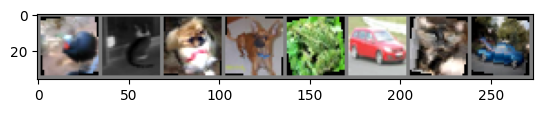

In [7]:
# create a function that can be visualizes the images

def show_images(img):
  # unnormalize the images
  img = img / 2 + 0.5
  # convert into numpy array
  npimg = img.numpy()
  # transpose with imshow:
  plt.imshow(np.transpose(npimg,(1,2,0)))
  # show images:
  plt.show()


show_images(torchvision.utils.make_grid(images[:8]))

# Training a CNN Network

In [8]:
class CNN(nn.Module):
  def __init__(self):
    super().__init__()

    self.network = nn.Sequential(
        nn.Conv2d(3,32,kernel_size=(3,3),padding="same"),   # Output: (32,32,32)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=(2,2)),        # Output: (32,16,16)

        nn.Conv2d(32,64,kernel_size=(3,3)),                    # Output: (64,14,14)
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=(2,2),stride=(2,2))       # Output: (64,7,7)

    )

    self.fc_layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(64*7*7,600),
        nn.ReLU(),
        nn.Linear(600,120),
        nn.ReLU(),
        nn.Linear(120,10)
    )

  def forward(self,x):
    x = self.network(x)
    x = self.fc_layer(x)
    return x


In [9]:
epochs = 10
learning_rate = 0.001

model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=learning_rate)


In [10]:
# model training:
total_step = len(train_dataloader)
model.train()
for epoch in range(epochs):
  for i,(images,labels) in enumerate(train_dataloader):
    images = images.to(device)
    labels = labels.to(device)

    # forward pass :
    output = model(images)
    loss = criterion(output,labels)

    # backpropagation:
    optimizer.zero_grad()
    loss.backward()

    # weight updation:
    optimizer.step()

    # printing the loss:
    if (i+1) % 100 == 0:
      print(f" Epochs {epoch + 1}/{epochs}, Steps : {i+1}/{total_step}, Loss : {loss.item():.4f}")

# validation :
model.eval()
with torch.no_grad():

  correct = 0
  total = 0

  for images,labels in test_dataloader:

    images = images.to(device)
    labels = labels.to(device)

    output = model(images)

    _,predicted = torch.max(output.data,1)
    correct += (predicted == labels).sum().item()
    total += labels.size(0)

  print(f"Accuracy of the model on the 10000 test images: {100 * correct / total:.2f}%")


 Epochs 1/10, Steps : 100/500, Loss : 1.6975
 Epochs 1/10, Steps : 200/500, Loss : 1.5395
 Epochs 1/10, Steps : 300/500, Loss : 1.4259
 Epochs 1/10, Steps : 400/500, Loss : 1.3725
 Epochs 1/10, Steps : 500/500, Loss : 1.2084
 Epochs 2/10, Steps : 100/500, Loss : 1.1715
 Epochs 2/10, Steps : 200/500, Loss : 1.4599
 Epochs 2/10, Steps : 300/500, Loss : 1.0878
 Epochs 2/10, Steps : 400/500, Loss : 1.1095
 Epochs 2/10, Steps : 500/500, Loss : 1.1833
 Epochs 3/10, Steps : 100/500, Loss : 1.1478
 Epochs 3/10, Steps : 200/500, Loss : 1.0380
 Epochs 3/10, Steps : 300/500, Loss : 0.9345
 Epochs 3/10, Steps : 400/500, Loss : 1.0978
 Epochs 3/10, Steps : 500/500, Loss : 0.7566
 Epochs 4/10, Steps : 100/500, Loss : 0.8006
 Epochs 4/10, Steps : 200/500, Loss : 0.8741
 Epochs 4/10, Steps : 300/500, Loss : 0.9000
 Epochs 4/10, Steps : 400/500, Loss : 0.7622
 Epochs 4/10, Steps : 500/500, Loss : 0.8999
 Epochs 5/10, Steps : 100/500, Loss : 0.8308
 Epochs 5/10, Steps : 200/500, Loss : 0.8164
 Epochs 5/